In [10]:
import os
import pickle
import random
import numpy as np
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style Setup from your notebook ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "text.usetex": False,                 
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",             
    "mathtext.rm": "serif"
})

print("Libraries imported and style set.")

Libraries imported and style set.


In [11]:
def load_data(eval_dir="data/cmnist/results_empirical"):
    path = os.path.join(eval_dir, "cmnist_Dll_samples.pkl")
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return None
        
    print(f"Loading samples from: {path}")
    with open(path, "rb") as f:
        Dll_samples = pickle.load(f)
    
    # Extract images from the first available key
    first_key = list(Dll_samples.keys())[0]
    ll_imgs, _, _, _ = Dll_samples[first_key]
    return ll_imgs

# Load the images (cached in memory)
raw_images_pool = load_data()
if raw_images_pool is not None:
    print(f"Loaded pool of {len(raw_images_pool)} images.")

Loading samples from: data/cmnist/results_empirical/cmnist_Dll_samples.pkl
Loaded pool of 2000 images.


In [12]:
def build_camera_transform(rotation_deg, brightness_factor):
    transforms = []
    
    # 1. Rotation (Deterministic)
    if rotation_deg != 0:
        transforms.append(T.RandomAffine(
            degrees=(rotation_deg, rotation_deg), 
            translate=(0.1, 0.1), 
            scale=None, 
            fill=0 
        ))
    
    # 2. Brightness (Deterministic)
    if brightness_factor != 1.0:
        transforms.append(T.Lambda(lambda img: TF.adjust_brightness(img, brightness_factor)))
        
    if len(transforms) == 0:
        return T.Lambda(lambda x: x)
    return T.Compose(transforms)

def apply_transform_batch(X_flat, transform, seed=42):
    """Applies rotation/lighting in [0,1] space."""
    N = X_flat.shape[0]
    X_img = X_flat.view(N, 3, 32, 32)
    
    # Denormalize [-1,1] -> [0,1] for correct lighting/fill
    X_01 = (X_img + 1) * 0.5
    X_shifted = torch.empty_like(X_01)
    
    for i in range(N):
        s = (int(seed) + i) % (2**32)
        torch.manual_seed(s); np.random.seed(s); random.seed(s)
        X_shifted[i] = transform(X_01[i])
    
    # Renormalize -> [-1,1]
    X_out = X_shifted * 2 - 1
    return torch.clamp(X_out, -1, 1).view(N, -1)

def apply_huber_noise(X_flat, alpha, noise_scale=0.5, seed=42):
    """Applies Huber contamination (alpha=0 is clean, alpha=1 is noisy)."""
    if alpha <= 0: return X_flat
    
    N = X_flat.shape[0]
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    
    mask = torch.rand(N, 1) < alpha
    noise = torch.randn_like(X_flat) * noise_scale
    X_corrupt = torch.where(mask, X_flat + noise, X_flat)
    return torch.clamp(X_corrupt, -1, 1)

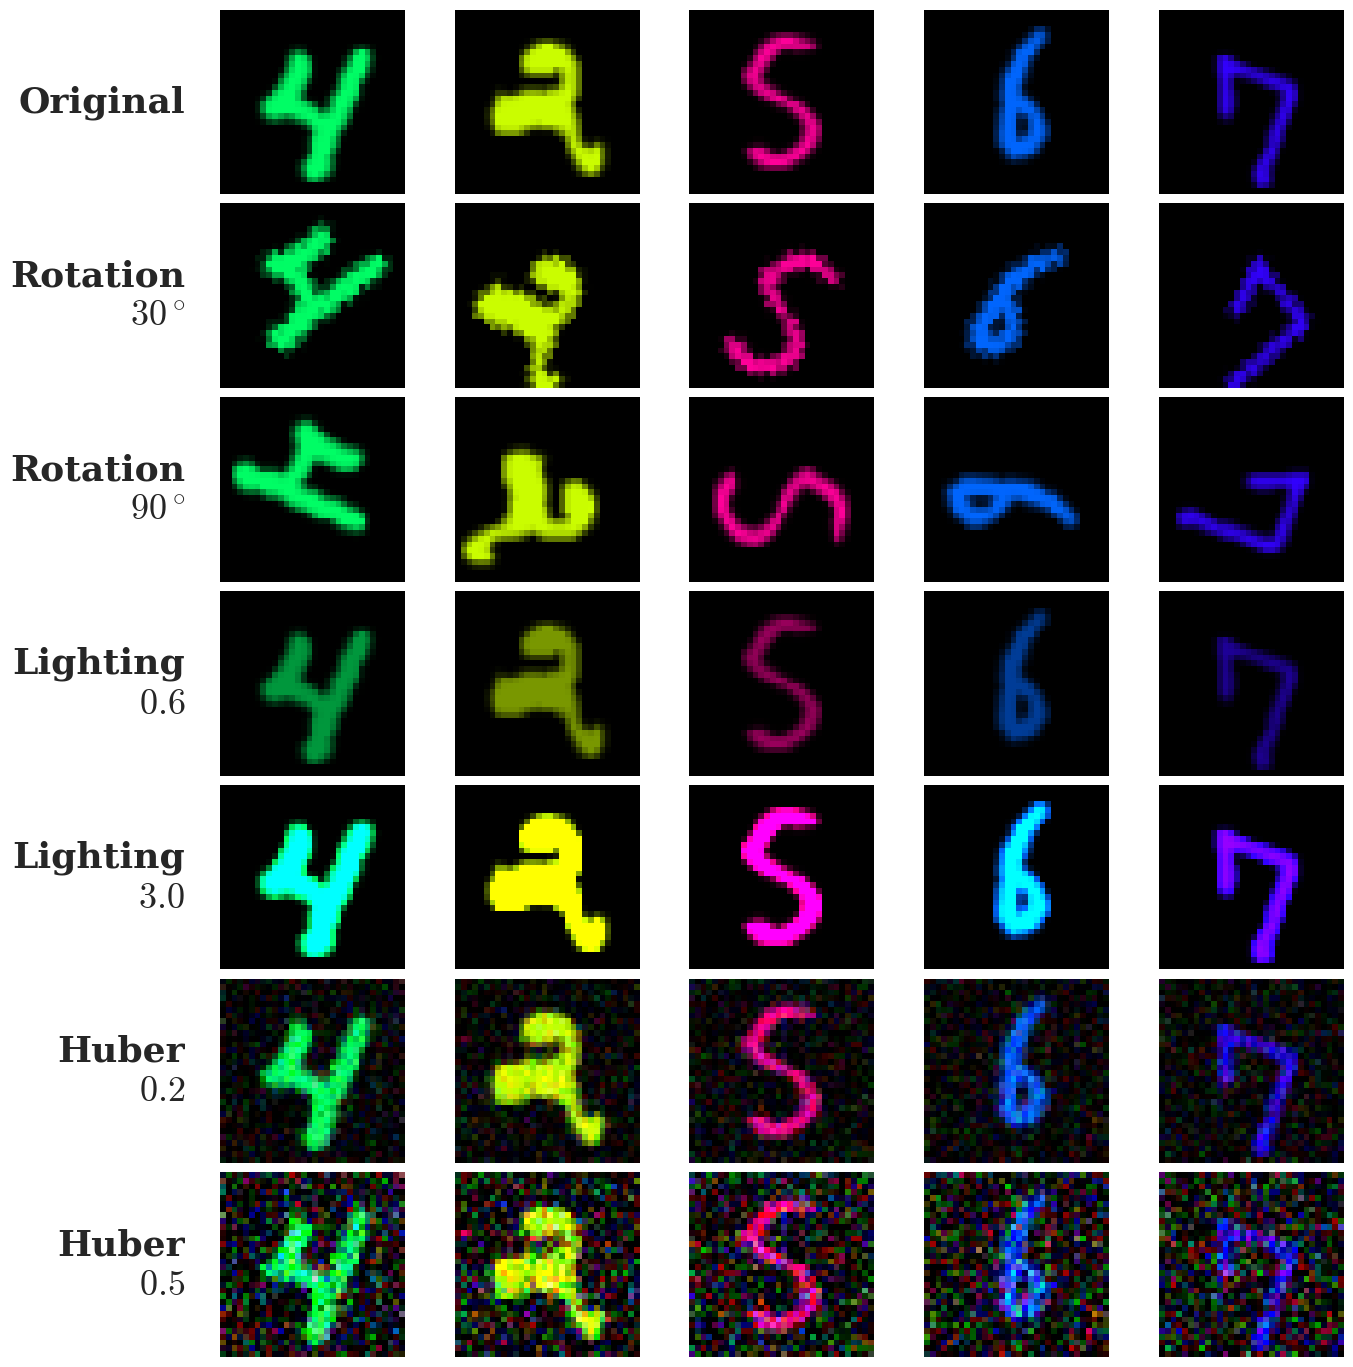

In [15]:
NUM_SAMPLES = 5          # Number of columns
SEED = 4                # Seed for sample selection

# Define the 7 Rows configuration
row_configs = [
    {"title": r"Original", 
     "rot": 0, "light": 1.0, "alpha": 0.0, "scale": 0.0},
    
    {"title": r"Rotation" + "\n" + r"$30^\circ$", 
     "rot": 30.0, "light": 1.0, "alpha": 0.0, "scale": 0.0},
    
    {"title": r"Rotation" + "\n" + r"$90^\circ$", 
     "rot": 90.0, "light": 1.0, "alpha": 0.0, "scale": 0.0},
    
    {"title": r"Lighting" + "\n" + r"$0.6$", 
     "rot": 0, "light": 0.6, "alpha": 0.0, "scale": 0.0},
    
    {"title": r"Lighting" + "\n" + r"$3.0$", 
     "rot": 0, "light": 3.0, "alpha": 0.0, "scale": 0.0},
    
    {"title": r"Huber" + "\n" + r"$0.2$", 
     "rot": 0, "light": 1.0, "alpha": 1.0, "scale": 0.2},
    
    {"title": r"Huber" + "\n" + r"$0.5$", 
     "rot": 0, "light": 1.0, "alpha": 1.0, "scale": 0.5},
]
# ==========================================

if raw_images_pool is not None:
    # 1. Select Random Samples
    np.random.seed(SEED)
    indices = np.random.choice(len(raw_images_pool), NUM_SAMPLES, replace=False)
    # Use torch.index_select for reliable tensor indexing
    indices_tensor = torch.tensor(indices, dtype=torch.long)
    # Determine the dimension to index along (usually 0 for first dimension)
    batch_raw = torch.index_select(raw_images_pool, 0, indices_tensor)
    X_flat_orig = (batch_raw * 2 - 1).view(NUM_SAMPLES, -1)
    
    # 2. Helper to process image for plotting
    def to_plot(tensor):
        # Use PyTorch operations to avoid numpy compatibility issues
        img = tensor.view(-1, 3, 32, 32).permute(0, 2, 3, 1)
        img_normalized = torch.clamp((img + 1) / 2.0, 0, 1)
        return img_normalized.numpy()

    # 3. Setup Plot with 7 Rows
    fig, axes = plt.subplots(len(row_configs), NUM_SAMPLES, 
                             figsize=(3 * NUM_SAMPLES, 2.5 * len(row_configs)))
    
    # Adjust spacing: hspace controls vertical gap
    plt.subplots_adjust(wspace=0.05, hspace=0.05) 

    # 4. Generate and Plot Each Row
    for r, config in enumerate(row_configs):
        # Build Transform
        tf = build_camera_transform(config["rot"], config["light"])
        
        # Apply Geometric/Lighting Shift
        X_shifted = apply_transform_batch(X_flat_orig, tf, seed=SEED)
        
        # Apply Huber Noise
        X_final = apply_huber_noise(X_shifted, config["alpha"], 
                                    noise_scale=config["scale"], seed=SEED)
        
        # Convert to visual format
        imgs_vis = to_plot(X_final)
        
        # Add Row Label (Annotation)
        # We place it to the left of the first image in the row
        axes[r, 0].annotate(config["title"], 
                            xy=(0, 0.5), xytext=(-25, 0),
                            xycoords='axes fraction', textcoords='offset points',
                            size=26, ha='right', va='center', fontweight='bold',
                            fontfamily='serif')

        for c in range(NUM_SAMPLES):
            ax = axes[r, c]
            ax.imshow(imgs_vis[c])
            ax.axis('off')
            ax.set_aspect('equal')

    plt.show()
else:
    print("Error: Images not loaded. Please run the Data Loading cell first.")